In [1]:
import scanpy as sc
import hdf5plugin
import anndata as ad

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn.objects  as so

from scipy.stats import chi2_contingency, false_discovery_control, mannwhitneyu
from scipy.stats import pearsonr,spearmanr
from sklearn.metrics import mean_squared_error, r2_score

import decoupler as dc
import os

from tqdm import tqdm

In [2]:
import importlib
importlib.reload(dc)

<module 'decoupler' from '/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/decoupler/__init__.py'>

# Load Data:

In [2]:
def ctrl_pert_split_dataset(norm_data: ad.AnnData) -> tuple[list[str], dict[str,list[str]]]:
    # Split df into perturbed and control cells
    by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
    # Find indices for each perturbation
    pert_i_dict = {pert.iloc[0]["perturbation"]:pert.index.to_list() for pert in by_pert}
    # Extract the control cells separately
    ctrl_i_vec = pert_i_dict.pop("ctrl")
    return (ctrl_i_vec, pert_i_dict)

In [3]:
grn_file = "doro_abcd_only"
names = ["Norman19","Replogle22"]
models = ["experimental","pGRiNS"]#, "Random"]

models_rand = ["pGRiNS","Random"]

In [ ]:
data = {}
for name in names:
    data[name] = {}
    for model in models:
        data[name][model] = {}
    data[name]["experimental"]["adata"] = sc.read_h5ad(f"../Data/Experimental/{name}/perturb_norm_subset_{grn_file}.h5ad")
    #perts = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())[:10]
    #data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][data[name]["experimental"]["adata"].obs["perturbation"].isin(["ctrl"]+perts)]

pgrins_full = sc.read_h5ad(f"../Data/Projects/{grn_file}/001/perturb_norm_pert.h5ad")
data["Norman19"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["perturbation"].isin(data["Norman19"]["experimental"]["adata"].obs["perturbation"]),data["Norman19"]["experimental"]["adata"].var_names]
data["1Replogle22"]["pGRiNS"]["adata"] = pgrins_full[pgrins_full.obs["perturbation"].isin(data["Replogle22"]["experimental"]["adata"].obs["perturbation"]),data["Replogle22"]["experimental"]["adata"].var_names]

for name in names:
    data[name]["experimental"]["adata"] = data[name]["experimental"]["adata"][:,list(set(data[name]["experimental"]["adata"].var_names)&set(data[name]["pGRiNS"]["adata"].var_names))]
    data[name]["perts"] = list(data[name]["experimental"]["adata"].obs["perturbation"].unique())
    data[name]["perts"].remove("ctrl")
    for model in models:
        data[name][model]["pert_indices"] = ctrl_pert_split_dataset(data[name][model]["adata"])
        data[name][model]["pert_means"] = {pert : np.asarray(np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"],axis=0)).squeeze() for pert in tqdm(data[name]["perts"])}

/tmp/ipykernel_71379/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 13/13 [00:01<00:00,  6.68it/s]
/tmp/ipykernel_71379/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_pert = [pert for _, pert in norm_data.obs.groupby(norm_data.obs["perturbation"])]
100%|██████████| 13/13 [00:00<00:00, 21.01it/s]
/tmp/ipykernel_71379/3870400248.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to ret

# Visual comparison:

In [33]:
perts = list(pgrins_full.obs["perturbation"].unique())
perts.remove("ctrl")

In [34]:
pgenes = set().union(*[set(p.split("_")) for p in perts])

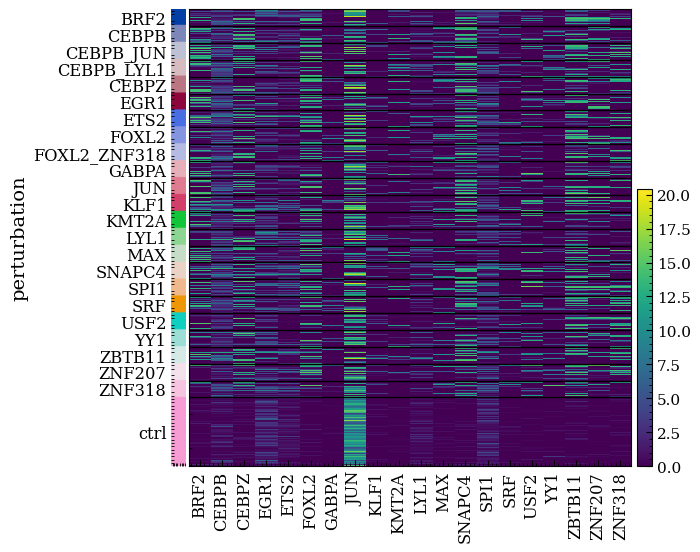

In [35]:
sc.pl.heatmap(pgrins_full,sorted(list(pgenes)),"perturbation",layer="log1p")

In [37]:
pgrins_full.obs

,PertNum,InitCondNum,ParamNum,SteadyStateFlag,Time,perturbation,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes
-1_1_11_0,-1,1,11,0,3,ctrl,1951,7.576610,1.223184e+11,25.529893,99.999805
-1_1_16_1,-1,1,16,0,11,ctrl,1930,7.565793,7.127901e+10,24.989868,99.999740
-1_1_33_2,-1,1,33,0,3,ctrl,1881,7.540090,1.089805e+11,25.414435,99.999760
-1_1_36_3,-1,1,36,0,2,ctrl,1979,7.590852,1.150413e+11,25.468557,99.999792
-1_1_131_4,-1,1,131,0,5,ctrl,1965,7.583756,1.034951e+11,25.362790,99.999777
...,...,...,...,...,...,...,...,...,...,...,...
22_66_907_27074,22,66,907,0,0,ZNF207,2008,7.605392,1.885587e+09,21.357505,99.988054
22_49_174_27075,22,49,174,0,1,ZNF207,2010,7.606387,5.514152e+10,24.733169,99.999555
22_1_821_27076,22,1,821,1,153,ZNF207,1946,7.574045,1.817581e+05,12.110438,7.906617
22_2_680_27077,22,2,680,0,7,ZNF207,1984,7.593374,1.070951e+10,23.094398,99.998173


In [ ]:
# visualization method: heatmap

# Shared DEGs:

In [ ]:
#median?

In [10]:
for name in names:
    for model in models:
        sc.tl.rank_genes_groups(data[name][model]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis_ctrl",rankby_abs=True,layer="log1p")
        data[name][model]["DEGs"] = {pert : data[name][model]["adata"].uns["DEG_analysis_ctrl"]["names"][pert][data[name][model]["adata"].uns["DEG_analysis_ctrl"]["pvals_adj"][pert] < 0.05] for pert in tqdm(data[name]["perts"])}
        #data[name][model]["ON_genes"] = {pert : data[name][model]["adata"].var_names[data[name][model]["pert_means"][pert]>np.mean(data[name][model]["pert_means"][pert])] for pert in tqdm(data[name]["perts"])}
    data[name]["Random"] = {}
    data[name]["Random"]["DEGs"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["DEGs"][pert])) for pert in tqdm(data[name]["perts"])}
    #data[name]["Random"]["ON_genes"] = {pert: np.random.choice(list(data[name]["pGRiNS"]["adata"].var_names),size=len(data[name]["pGRiNS"]["ON_genes"][pert])) for pert in tqdm(data[name]["perts"])}

100%|██████████| 13/13 [00:00<00:00, 10405.72it/s]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
100%|██████████| 10/10 [00:00<00:00, 8126.92it/s]
/home/gesomme/Code/venvs/vbsc/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:679: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
100%|██████████| 10/10 [00:00<00:00, 523.59it/s]


In [11]:
chisq_res = {}
for test in ["DEGs"]:#,"ON_genes"]:
    chisq_res[test] = {}
    for model in ["pGRiNS","Random"]:
        chisq_res[test][model] = {}
        chisq_res[test][model]["pvals"] = []
        for name in names:
            for pert in data[name]["perts"]:
                genes_exp_set = set(data[name]["experimental"][test][pert])
                all_genes = set(data[name]["experimental"]["adata"].var_names)
                genes_model_set = set(data[name][model][test][pert])
                # Get contingency matrix
                count_matrix = np.array([[len(genes_exp_set & genes_model_set),len(genes_model_set - genes_exp_set)],[len(genes_exp_set - genes_model_set),len(all_genes - (genes_exp_set|genes_model_set))]])
                res = chi2_contingency(count_matrix)
                chisq_res[test][model]["pvals"].append(res.pvalue)
        chisq_res[test][model]["pvals_adj"] = false_discovery_control(chisq_res[test][model]["pvals"]) # Benjamini-Hochberg correction due to large number of p values
        


In [13]:
import plotting_funs

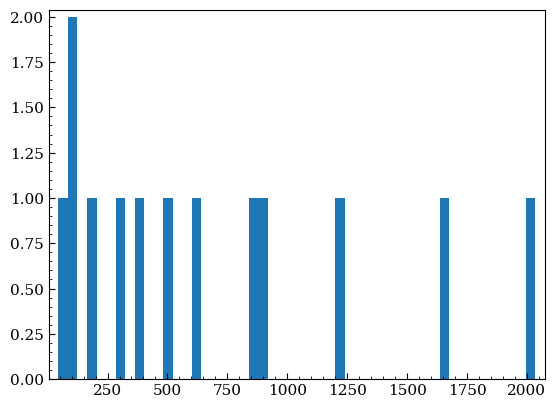

In [28]:
plt.hist([len(x) for x in data["Norman19"]["experimental"]["DEGs"].values()],bins=50)
plt.show()

In [14]:
prop_cycle= plotting_funs.set_mpl_attributes()

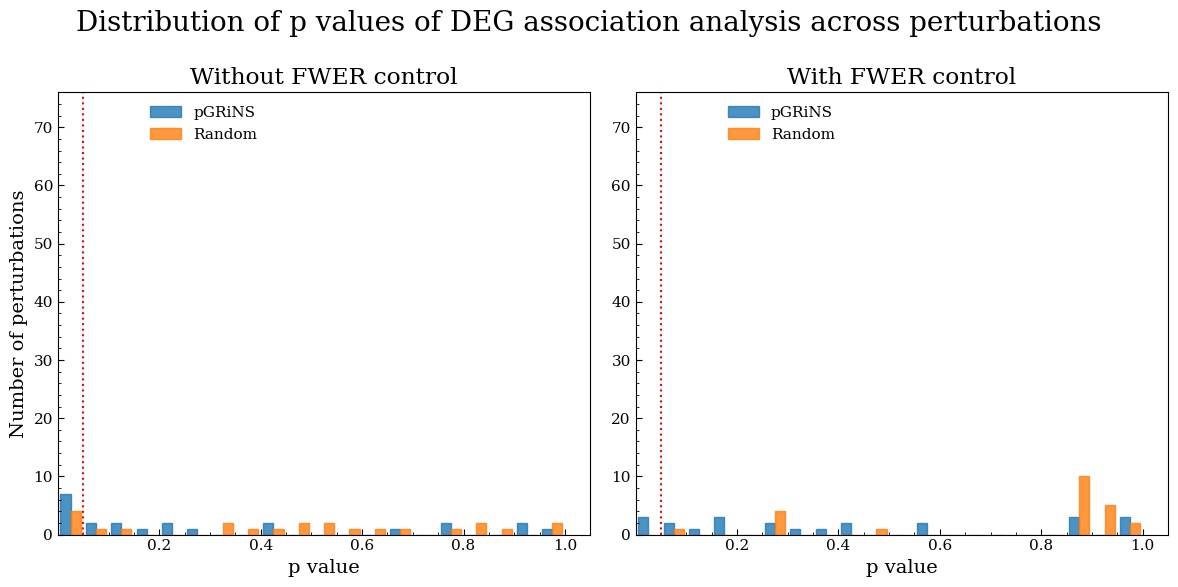

In [15]:
fig, axs = plt.subplots(1,2,figsize=(12,6))
axs[0].hist([chisq_res["DEGs"]["pGRiNS"]["pvals"],chisq_res["DEGs"]["Random"]["pvals"]],bins=20,label=["pGRiNS","Random"],color=[prop_cycle[0],prop_cycle[1]],alpha=0.8,lw=1,edgecolor=[prop_cycle[0],prop_cycle[1]])
axs[0].vlines(0.05,0,76,color="red",linestyles="dotted")
axs[0].set_ylim(0,76)
axs[0].set_xlim(0.000001,1.05)
axs[0].set_title("Without FWER control")
axs[0].legend(bbox_to_anchor=(0.4,1))
axs[0].set_ylabel("Number of perturbations")
axs[0].set_xlabel("p value")

axs[1].hist([chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"]],label=["pGRiNS","Random"],bins=20,color=[prop_cycle[0],prop_cycle[1]],alpha=0.8,lw=1,edgecolor=[prop_cycle[0],prop_cycle[1]])
axs[1].vlines(0.05,0,76,color="red",linestyles="dotted")
axs[1].set_ylim(0,76)
axs[1].set_xlim(0.0000001,1.05)
axs[1].set_title("With FWER control")
axs[1].legend(bbox_to_anchor=(0.4,1))
axs[1].set_xlabel("p value")
fig.suptitle("Distribution of p values of DEG association analysis across perturbations")
fig.tight_layout()
os.makedirs(f"Plots/{grn_file}/001",exist_ok=True)
plt.savefig(f"Plots/{grn_file}/001/DEG_pvals.png")
plt.show()

In [16]:
u_deg = mannwhitneyu(chisq_res["DEGs"]["pGRiNS"]["pvals_adj"],chisq_res["DEGs"]["Random"]["pvals_adj"],alternative="two-sided")
print(u_deg.pvalue) # 2.718303674376062e-08

0.006567550871476484


# Compare using metrics:

In [17]:
for name in names:
    sc.tl.rank_genes_groups(data[name]["experimental"]["adata"],groupby="perturbation",reference="rest",key_added="DEG_analysis_Mejia",method="t-test_overestim_var",layer="log1p")
    data[name]["experimental"]["weights_Mejia"] = {}
    for pert in data[name]["perts"]:
        pert_weights = data[name]["experimental"]["adata"].uns["DEG_analysis_Mejia"]["scores"][pert]
        pert_weights = np.abs(pert_weights) # Absolute value transformation
        pert_weights = (pert_weights-min(pert_weights))/(max(pert_weights)-min(pert_weights)+1e-8) # Min-max transformation to [0,1]
        pert_weights = pert_weights**2 # Squaring
        pert_weights = pert_weights/sum(pert_weights) # Normalization
        pert_weights = pert_weights[np.argsort(data[name]["experimental"]["adata"].uns["DEG_analysis_Mejia"]["names"][pert])] # Bring them in the correct order (so that the corresponding genes are ordered alphabetically)
        data[name]["experimental"]["weights_Mejia"][pert] = pert_weights
    

In [18]:
metrics = {
    "MSE":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : mean_squared_error(avg_expr_GT_pert, avg_expr_pred),
    "wMSE":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2),
    "Pearson":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed,weights : pearsonr(x=avg_expr_GT_pert, y=avg_expr_pred).correlation,
    "Pearson Delta":lambda avg_expr_GT_pert,avg_expr_pred, mean_unperturbed,weights : 0.0 if (avg_expr_pred == mean_unperturbed).all() else pearsonr(x=avg_expr_GT_pert-mean_unperturbed, y=avg_expr_pred-mean_unperturbed).correlation,
    "Weighted Delta R2":lambda avg_expr_GT_pert, avg_expr_pred, mean_unperturbed, weights: 1-(np.dot(weights,(avg_expr_GT_pert-avg_expr_pred)**2))/(np.dot(weights,(avg_expr_GT_pert-mean_unperturbed-np.dot(weights,(avg_expr_GT_pert-mean_unperturbed)))**2)) # 0.0 if (avg_expr_pred == mean_unperturbed).all() else 
    }

metric_names = list(metrics.keys())
metric_names = metric_names[:3]

In [19]:
# For every perturbation: calculate the WMSE between the experimental data mean and each cell of the model
cellwise_metric = {}
for name in names:
    print(name)
    cellwise_metric[name] = {}
    exp_pert_mean = np.mean(np.vstack(list(data[name]["experimental"]["pert_means"].values())),axis=0) # µ_all
    for model in models:
        print(model)
        cellwise_metric[name][model] = {}
        for m in metric_names:
            print(m)
            cellwise_metric[name][model][m] = []
            for pert in tqdm(data[name]["perts"]):
                cell_mean = np.mean(data[name][model]["adata"][data[name][model]["pert_indices"][1][pert]].layers["log1p"].todense(),axis=0)
                m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(cell_mean).squeeze(),exp_pert_mean,data[name]["experimental"]["weights_Mejia"][pert])
                cellwise_metric[name][model][m].append(m_mean)
    # Negative baseline: WMSE between each experimental control cell and the experimental data mean
    cellwise_metric[name]["ctrl_baseline"] = {}
    print("ctrl_baseline")
    control_mean = np.mean(data[name]["experimental"]["adata"][data[name]["experimental"]["pert_indices"][0]].layers["log1p"].todense(),axis=0)
    for m in metric_names:
        print(m)
        cellwise_metric[name]["ctrl_baseline"][m] = []
        for pert in tqdm(data[name]["perts"]):
            m_mean = metrics[m](data[name]["experimental"]["pert_means"][pert],np.asarray(control_mean).squeeze(),exp_pert_mean,data[name]["experimental"]["weights_Mejia"][pert])
            cellwise_metric[name]["ctrl_baseline"][m].append(m_mean)

# Hypothesis: all normally distributed, mu_p,exp < mu_p,pgrins << mu_c,exp

# is the order of pval_adj or t score alphabetically? Or are they reordered according to pval?

Norman19
experimental
MSE


100%|██████████| 13/13 [00:01<00:00,  6.80it/s]


wMSE


100%|██████████| 13/13 [00:01<00:00,  6.90it/s]


Pearson


...

100%|██████████| 10/10 [00:00<00:00, 1282.15it/s]


wMSE


100%|██████████| 10/10 [00:00<00:00, 3717.04it/s]


Pearson


100%|██████████| 10/10 [00:00<00:00, 846.43it/s]


In [20]:
pgrins_ctrl_mean = np.asarray(np.mean(data[name]["pGRiNS"]["adata"][data[name]["pGRiNS"]["adata"].obs["perturbation"] == "ctrl"].layers["log1p"].todense(),axis=0)).squeeze()
ctrl_mean = np.asarray(np.mean(data[name]["experimental"]["adata"][data[name]["experimental"]["adata"].obs["perturbation"]=="ctrl"].layers["log1p"].todense(),axis=0)).squeeze()
metrics["MSE"](pgrins_ctrl_mean,ctrl_mean,exp_pert_mean,data[name]["experimental"]["weights_Mejia"][pert])


0.6563855083522598

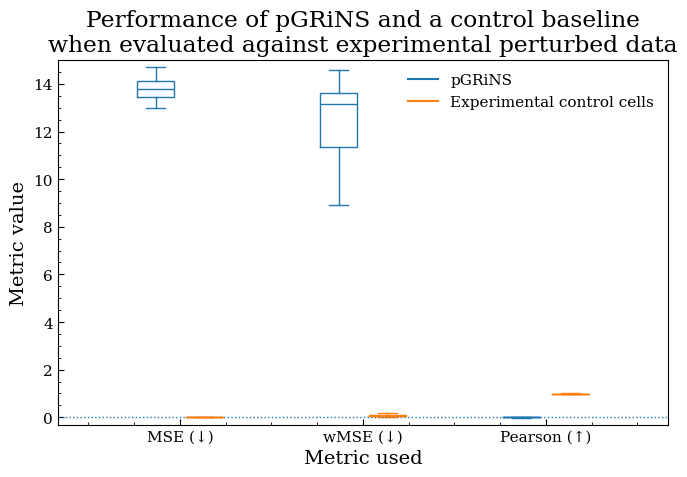

In [21]:
def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)
    plt.setp(bp['medians'], color=color)

plt.figure(figsize=(7,5))
bpl = plt.boxplot([cellwise_metric["Norman19"]["pGRiNS"][m]+cellwise_metric["Replogle22"]["pGRiNS"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0-0.4, sym='', widths=0.6)
bpr = plt.boxplot([cellwise_metric["Norman19"]["ctrl_baseline"][m]+cellwise_metric["Replogle22"]["ctrl_baseline"][m] for m in metric_names],positions=np.array(np.arange(len(metric_names)))*3.0+0.4, sym='', widths=0.6)
plt.plot([], c=prop_cycle[0], label='pGRiNS')
plt.plot([], c=prop_cycle[1], label='Experimental control cells')
plt.hlines(0,-3, len(metric_names) * 3,linestyles="dotted",lw=1)
plt.legend()
set_box_color(bpl, prop_cycle[0])
set_box_color(bpr, prop_cycle[1])
#plt.ylim(-1,1)
plt.xticks(range(0, len(metric_names) * 3, 3), [metric_names[0]+" (↓)",metric_names[1]+" (↓)",metric_names[2]+" (↑)"])
plt.xlim(-3+1, len(metric_names)*3-1)
plt.title("Performance of pGRiNS and a control baseline\nwhen evaluated against experimental perturbed data")
plt.xlabel("Metric used")
plt.ylabel("Metric value")
plt.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/metrics2.png")
plt.show()

# Pathways:

## GSEA:

- Inspired from https://www.sc-best-practices.org/conditions/gsea_pathway.html

In [43]:
# Retrieving via python
msigdb = dc.op.resource("MSigDB")

# Get reactome pathways
reactome = msigdb.query("collection == 'reactome_pathways'")
# Filter duplicates
reactome = reactome[~reactome.duplicated(("geneset", "genesymbol"))].rename(columns={"genesymbol":"target","geneset":"source"})

In [44]:
gsea_dict = {}
for name in names:
    gsea_dict[name] = {}
    # Filter reactome by genes in each dataset
    gsea_dict[name]["reactome"] = reactome[reactome["target"].isin(data[name]["experimental"]["adata"].var_names)]
    # Get the genesets with no. of genes in [15,500]
    geneset_size = gsea_dict[name]["reactome"].groupby("source").size()
    gsea_dict[name]["genesets"] = geneset_size.index[(geneset_size > 15) & (geneset_size < 500)] # ~600 genesets for both datasets
    for model in models:
        gsea_dict[name][model] = {}
        for pert in tqdm(data[name]["perts"]):
            t_stats = sc.get.rank_genes_groups_df(data[name][model]["adata"], pert, key="DEG_analysis_ctrl").set_index("names").sort_values("scores", key=np.abs, ascending=False)[["scores"]].rename_axis([pert], axis=1)
            scores, pvals = dc.mt.gsea(
                t_stats.T,
                gsea_dict[name]["reactome"][gsea_dict[name]["reactome"]["source"].isin(gsea_dict[name]["genesets"])],
            )
            gsea_dict[name][model][pert] = (
                pd.concat({"score": scores.T, "pval": pvals.T}, axis=1)
                .droplevel(level=1, axis=1)
                .sort_values("pval")
            )

100%|██████████| 10/10 [01:29<00:00,  8.90s/it]


In [124]:
gsea_dict[name]["pGRiNS"]["CHEK1"]

,score,pval
REACTOME_TRANSCRIPTIONAL_ACTIVATION_OF_MITOCHONDRIAL_BIOGENESIS,-1.510693,0.0
REACTOME_TOLL_LIKE_RECEPTOR_CASCADES,-1.454409,0.0
REACTOME_DEATH_RECEPTOR_SIGNALING,-2.010061,0.0
REACTOME_PROGRAMMED_CELL_DEATH,-1.585689,0.0
REACTOME_P75_NTR_RECEPTOR_MEDIATED_SIGNALLING,-1.697235,0.0
...,...,...
REACTOME_ACTIVATION_OF_NMDA_RECEPTORS_AND_POSTSYNAPTIC_EVENTS,0.866740,1.0
REACTOME_VESICLE_MEDIATED_TRANSPORT,0.928790,1.0
REACTOME_VIRAL_INFECTION_PATHWAYS,0.880044,1.0
REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,0.510306,1.0


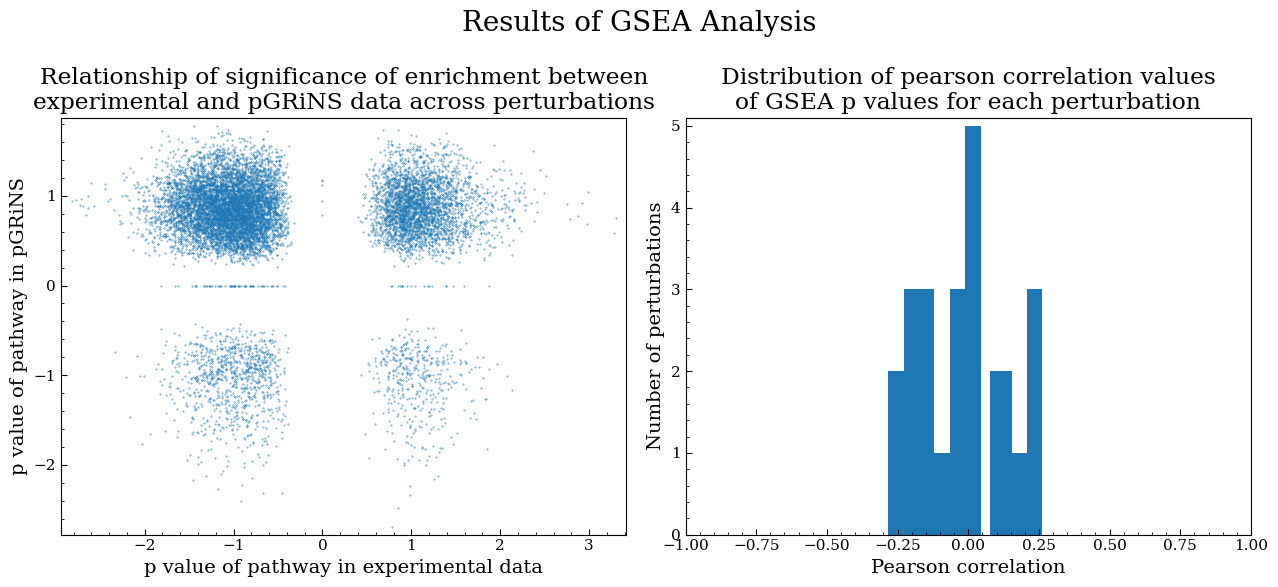

In [47]:
gsea_pearsons = []
fig,axs=plt.subplots(1,2,figsize=(13,6))
for name in names:
    for pert in data[name]["perts"]:
        gsea_pearsons.append(pearsonr(gsea_dict[name]["experimental"][pert].sort_index().score,gsea_dict[name]["pGRiNS"][pert].sort_index().score).correlation)
        axs[0].scatter(gsea_dict[name]["experimental"][pert].sort_index().score,gsea_dict[name]["pGRiNS"][pert].sort_index().score,s=0.1,c=prop_cycle[0])
    axs[0].set_ylabel("p value of pathway in pGRiNS")
    axs[0].set_xlabel("p value of pathway in experimental data")
    axs[0].set_title("Relationship of significance of enrichment between\nexperimental and pGRiNS data across perturbations")
    axs[1].hist(gsea_pearsons,bins=10,color=prop_cycle[0])
    axs[1].set_xlim(-1,1)
    axs[1].set_title("Distribution of pearson correlation values\nof GSEA p values for each perturbation")
    axs[1].set_ylabel("Number of perturbations")
    axs[1].set_xlabel("Pearson correlation")
fig.suptitle("Results of GSEA Analysis")
fig.tight_layout()
plt.savefig(f"Plots/{grn_file}/001/gsea.png")
plt.show()

## Coexpression Graph:
- Inspired from https://link.springer.com/protocol/10.1007/978-1-0716-2067-0_19

- Both GO analysis on modules, and graph comparison with CoDiNA
    - GSEA is done perturbation wise (can pGRiNS capture the specific pathways affected by a perturbation?)
    - GO is done across perturbations (are genes generally coexpressed in such a way that networks/pathways are derivable?   )

In [301]:
for name in names:
    for model in models:
        pert_mean_matrix = np.vstack(list(data[name][model]["pert_means"].values()))
        pd.DataFrame(pert_mean_matrix,columns=data[name][model]["adata"].var_names).to_csv(f"../Data/Experimental/{name}/{name}-{model}_pert_mean.csv",sep=" ",index=False)

# Used as input in coexpr.R

In [ ]:
for name in names:
    data[name][model]["diffnet"] = pd.read_csv(f"diffnet_{name}.csv",sep=" ")